<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial_11/Tutorial11_Semantic_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELL 1: Import Libraries and Setup Pre-trained DeepLabV3

In [1]:
# 1. Import Essential Libraries
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

# 2. Set Device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# 3. Load Pre-trained DeepLabV3 Model (trained on PASCAL VOC)
# We use the ResNet-101 backbone for high accuracy
weights = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights)

# Move model to device and set to Evaluation Mode (critical for inference)
model = model.to(device)
model.eval()
print("DeepLabV3-ResNet101 Model loaded successfully in eval mode!")

PyTorch Version: 2.10.0+cpu
Torchvision Version: 0.25.0+cpu
Using Device: cpu
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 139MB/s]


DeepLabV3-ResNet101 Model loaded successfully in eval mode!


CELL 2: Define Object Classes and Color Palette

In [3]:
# Define the 21 PASCAL VOC classes (Index 0 is always Background)
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Define a distinct RGB color palette for all 21 classes for visualization
VOC_COLORS = np.array([
    [0, 0, 0],         # 0: background (Black)
    [128, 0, 0],       # 1: aeroplane
    [0, 128, 0],       # 2: bicycle
    [128, 128, 0],     # 3: bird
    [0, 0, 128],       # 4: boat
    [128, 0, 128],     # 5: bottle
    [0, 128, 128],     # 6: bus
    [128, 128, 128],   # 7: car
    [64, 0, 0],        # 8: cat
    [192, 0, 0],       # 9: chair
    [64, 128, 0],      # 10: cow
    [192, 128, 0],     # 11: diningtable
    [64, 0, 128],      # 12: dog
    [192, 0, 128],     # 13: horse
    [64, 128, 128],    # 14: motorbike
    [192, 128, 128],   # 15: person
    [0, 64, 0],        # 16: pottedplant
    [128, 64, 0],      # 17: sheep
    [0, 192, 0],       # 18: sofa
    [128, 192, 0],     # 19: train
    [0, 64, 128]       # 20: tvmonitor
], dtype=np.uint8)

# Function to convert output class indices to a full RGB image map
def decode_segmentation_map(output_mask):
    # Map each pixel's class prediction to its corresponding RGB color
    rgb_mask = VOC_COLORS[output_mask]
    return rgb_mask

CELL 3: Image Pre-processing and Inference Pipeline

In [4]:
# Define standard validation pre-processing transforms
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # Standard ImageNet Mean
        std=[0.229, 0.224, 0.225]   # Standard ImageNet StdDev
    ),
])

def run_segmentation(image_path):
    # 1. Load Image
    input_image = Image.open(image_path).convert("RGB")
    original_size = input_image.size # (width, height)

    # 2. Pre-process Image
    input_tensor = preprocess(input_image)
    # Add batch dimension: shape becomes [1, Channels, Height, Width]
    input_batch = input_tensor.unsqueeze(0).to(device)

    # 3. Perform Inference
    print("Running inference through DeepLabV3...")
    with torch.no_grad(): # Disable gradient calculation for faster inference
        output = model(input_batch)['out'][0]

    # 4. Extract Final Mask
    # Output shape is [21, Height, Width]. We take argmax across classes (dim=0)
    output_predictions = output.argmax(0).byte().cpu().numpy()

    return input_image, output_predictions

print("Segmentation pipeline ready!")

Segmentation pipeline ready!


CELL 4: Test on Sample Image and Visualize Results

Running inference through DeepLabV3...
Detected Foreground Classes: ['dog']


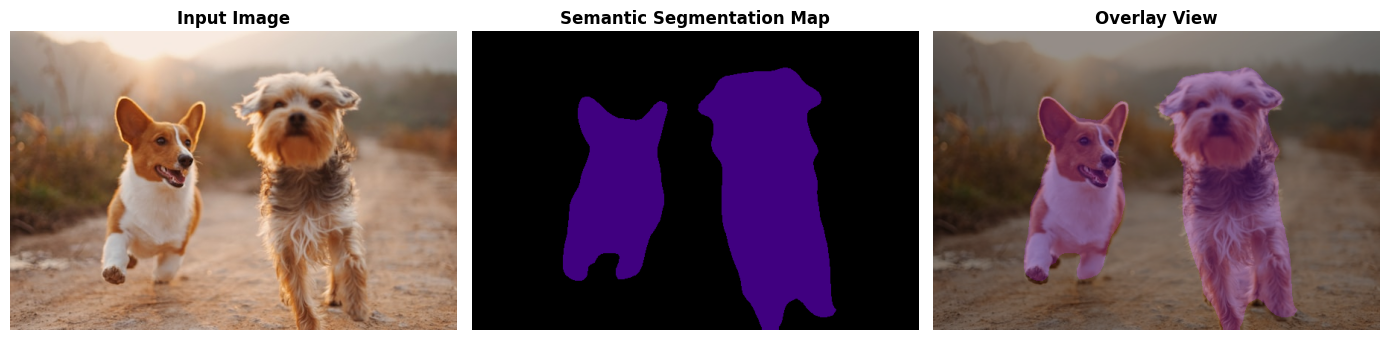

In [5]:
# Download a test image containing PASCAL VOC classes (Person and Dog)
url = "https://images.unsplash.com/photo-1548199973-03cce0bbc87b?w=600"
image_filename = "test_image.jpg"
urllib.request.urlretrieve(url, image_filename)

# Run pipeline
original_img, pred_mask = run_segmentation(image_filename)

# Decode mask to RGB color map
color_mask = decode_segmentation_map(pred_mask)

# Find unique detected classes in this image
detected_indices = np.unique(pred_mask)
detected_classes = [VOC_CLASSES[idx] for idx in detected_indices if idx != 0]
print(f"Detected Foreground Classes: {detected_classes}")

# Visualize Results
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.title("Input Image", fontweight='bold')
plt.imshow(original_img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Semantic Segmentation Map", fontweight='bold')
plt.imshow(color_mask)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay View", fontweight='bold')
# Overlay mask onto original image with 60% opacity
overlay = cv2.addWeighted(np.array(original_img), 0.6, color_mask, 0.4, 0)
plt.imshow(overlay)
plt.axis('off')

plt.tight_layout()
plt.savefig("deeplabv3_result.png", dpi=300)
plt.show()

In [1]:
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request
import time
from google.colab import files

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
print("Initializing environment...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

# Define PASCAL VOC classes and distinct color mapping for visualization
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

VOC_COLORS = np.array([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
], dtype=np.uint8)

# Standard ImageNet pre-processing
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def decode_segmap(mask):
    return VOC_COLORS[mask]

def segment_image(model, img_path):
    img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    start_time = time.time()
    with torch.no_grad():
        output = model(input_tensor)['out'][0]
    inf_time = time.time() - start_time

    preds = output.argmax(0).byte().cpu().numpy()
    return img, preds, inf_time

# ==============================================================================
# 2. BASE MODEL EXECUTION (DeepLabV3-ResNet101)
# ==============================================================================
print("Loading pre-trained DeepLabV3-ResNet101...")
weights_dl = torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model_dl = torchvision.models.segmentation.deeplabv3_resnet101(weights=weights_dl).to(device).eval()

# Download baseline sample image (Person and Dog)
url_base = "https://images.unsplash.com/photo-1548199973-03cce0bbc87b?w=600"
img_base_path = "base_sample.jpg"
urllib.request.urlretrieve(url_base, img_base_path)

img_base, mask_base, _ = segment_image(model_dl, img_base_path)
color_mask_base = decode_segmap(mask_base)

# Generate and save Base Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Input Image", fontweight='bold'); plt.imshow(img_base); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Segmentation Map", fontweight='bold'); plt.imshow(color_mask_base); plt.axis('off')
overlay_base = cv2.addWeighted(np.array(img_base), 0.6, color_mask_base, 0.4, 0)
plt.subplot(1, 3, 3); plt.title("Overlay View", fontweight='bold'); plt.imshow(overlay_base); plt.axis('off')
plt.tight_layout()
plt.savefig("base_deeplabv3_result.png", dpi=300)
plt.close()
files.download("base_deeplabv3_result.png")

# ==============================================================================
# 3. TASK 1: TEST ON REAL-WORLD VARIATIONS (Street Scene)
# ==============================================================================
print("Executing Task 1: Testing on novel real-world image...")
# Download an alternate complex image (Cars and People)
url_task1 = "https://images.unsplash.com/photo-1506015391300-4802dc74de2e?w=600"
img_task1_path = "task1_sample.jpg"
urllib.request.urlretrieve(url_task1, img_task1_path)

img_t1, mask_t1, _ = segment_image(model_dl, img_task1_path)
color_mask_t1 = decode_segmap(mask_t1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Task 1 Input (Street)", fontweight='bold'); plt.imshow(img_t1); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Extracted Features", fontweight='bold'); plt.imshow(color_mask_t1); plt.axis('off')
overlay_t1 = cv2.addWeighted(np.array(img_t1), 0.6, color_mask_t1, 0.4, 0)
plt.subplot(1, 3, 3); plt.title("Semantic Overlay", fontweight='bold'); plt.imshow(overlay_t1); plt.axis('off')
plt.tight_layout()
plt.savefig("task1_realworld_testing.png", dpi=300)
plt.close()
files.download("task1_realworld_testing.png")

# ==============================================================================
# 4. TASK 2: ARCHITECTURE COMPARISON (FCN-ResNet50 vs DeepLabV3)
# ==============================================================================
print("Executing Task 2: Loading lightweight FCN-ResNet50 for comparison...")
weights_fcn = torchvision.models.segmentation.FCN_ResNet50_Weights.DEFAULT
model_fcn = torchvision.models.segmentation.fcn_resnet50(weights=weights_fcn).to(device).eval()

# Run timing and visualization comparison on base image
_, mask_dl, time_dl = segment_image(model_dl, img_base_path)
_, mask_fcn, time_fcn = segment_image(model_fcn, img_base_path)

color_dl = decode_segmap(mask_dl)
color_fcn = decode_segmap(mask_fcn)

plt.figure(figsize=(10, 4.5))
plt.subplot(1, 2, 1)
plt.title(f"Heavy: DeepLabV3-ResNet101\nInference: {time_dl*1000:.1f} ms", fontweight='bold', fontsize=11)
plt.imshow(color_dl); plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Light: FCN-ResNet50\nInference: {time_fcn*1000:.1f} ms", fontweight='bold', fontsize=11)
plt.imshow(color_fcn); plt.axis('off')

plt.tight_layout()
plt.savefig("task2_model_comparison.png", dpi=300)
plt.close()
files.download("task2_model_comparison.png")

print("All tasks processed successfully! Images downloaded.")

Initializing environment...
Using Device: cuda
Loading pre-trained DeepLabV3-ResNet101...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:01<00:00, 163MB/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Executing Task 1: Testing on novel real-world image...


...

Executing Task 2: Loading lightweight FCN-ResNet50 for comparison...
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 174MB/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All tasks processed successfully! Images downloaded.
